# NYC Taxi Fare Amount — Tuned Model

- Caleb Solomons
- Mubeen Yaqub
- Mai Lam
- Anh Minh Tran

**DSCI 592 Capstone — Team GridRunners**
**Target:** `fare_amount` (regression)
**Predecessor:** `fare_amount_baseline.ipynb` (XGBoost — RMSE $3.82, R2 0.947 on 1.5M-row stratified sample)

This notebook advances the baseline along six concrete axes:


**Optuna hyperparameter sweep**  TPE-driven search over depth, learning rate, regularization. Replaces hand-picked starter params.

**XGBoost native categorical** Drops one-hot encoding entirely. Lower memory, fewer columns, cleaner feature-importance plots.

**K-fold cross-validation** 5-fold replaces the single 80/20. Reported metric is now mean ± std across folds — a real generalization estimate, not a one-shot lucky split.

**Feature engineering** Weather joins (temp / precip), event-day flags (federal holidays + NYC events), and routing-API-style distance proxies (haversine + Manhattan-L1 between borough centroids).

**Residual investigation** Worst-miss rows are sliced by hour, borough pair, distance bin, and fare bin to identify systematic failure modes and propose tighter sanity bounds.

**Full-dataset run** Gated by a config flag. Once tuning is locked, retrain on the entire cleaned parquet rather than the 1.5M sample.

> Edit the cells marked `# >>> EDIT <<<` to point at your Drive paths. Everything else is parameterized through the config block in Section 2.

Update on 5-13-2026, fixed ratecodeID not being processed earlier on.

## 1. Setup

In [ ]:
!pip -q install optuna meteostat

In [ ]:

import json
import math
import warnings
from datetime import date
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


import xgboost as xgb


import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-trial spam

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
sns.set_style("whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | optuna {optuna.__version__}")

pandas 3.0.3 | numpy 2.0.2 | xgboost 3.2.0 | optuna 4.8.0


## 2. Config Tuning

In [ ]:
# sampling

SAMPLE_SIZE = 1_500_000   
TUNING_SAMPLE = 250_000    
USE_FULL_DATASET = False      # if True, Section 12 retrains on the full parquet

# search

N_TRIALS = 30                
CV_FOLDS = 5                 

# bounds

FARE_MIN, FARE_MAX = 3.0, 150.0
DIST_MIN, DIST_MAX = 0.3, 50.0

# feature engineering

ENABLE_WEATHER_JOIN = True            # tries Open-Meteo, falls back to synthetic
ENABLE_EVENT_FLAGS = True
ENABLE_DISTANCE_PROXIES = True


XGB_DEVICE = "cuda"           

## 3. Mount Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# >>> EDIT <<<  Paths
#                          >>VV EDIT ME VV<<
DRIVE_BASE = Path("/content/drive/MyDrive/DSCI 592")
DATA_PATH = Path("/content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet")

OUTPUT_DIR = DRIVE_BASE / "v2_tuned_fare"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"

for d in (OUTPUT_DIR, FIGURE_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Reading data from : {DATA_PATH}")
print(f"Saving outputs to : {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading data from : /content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet
Saving outputs to : /content/drive/MyDrive/DSCI 592/v2_tuned_fare


## 4. Load Data & Inspect Columns

In [ ]:
df_full = pd.read_parquet(DATA_PATH)

print(f"Full dataset shape : {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")
print(f"Memory footprint : {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB\n")
print("Columns and dtypes:")
print(df_full.dtypes.to_string())

Full dataset shape : 37,017,621 rows × 35 cols
Memory footprint   : 14.03 GB

Columns and dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_min               float64
speed_mph                       float64
pickup_hour                       int32
pickup_dow            

## 5. Column Mapping & Leakage Discipline

Only features known at trip-request time:
- `trip_distance` (would be a routing-API estimate in production)
- `passenger_count`
- Pickup-time features: hour, day-of-week, weekend
- Pickup & dropoff borough
- `VendorID`

Built in the next three sections:
- `temp_f`, `precip_in`, `is_rainy` (weather, joined by date)
- `is_us_holiday`, `is_nyc_event` (event-day flags)
- `haversine_mi`, `manhattan_mi` (distance proxies between borough centroids)

In [ ]:
COL = {
    "target":         "fare_amount",
    "trip_distance":  "trip_distance",
    "passengers":     "passenger_count",
    "hour":           "pickup_hour",
    "dow":            "pickup_dow",
    "weekend":        "is_weekend",
    "pu_borough":     "PU_borough",
    "do_borough":     "DO_borough",
    "vendor":         "VendorID",
    "pickup_dt":      "tpep_pickup_datetime",
    "ratecode":       "RatecodeID", ###
}


NUMERIC_BASE = [COL["trip_distance"], COL["passengers"]]

CATEGORICAL_BASE = [COL["hour"], COL["dow"], COL["weekend"],
                    COL["pu_borough"], COL["do_borough"], COL["vendor"],
                    COL["ratecode"]]   ###
TARGET = COL["target"]


# engineered features get appended in their own sections.

ENG_NUMERIC = []
ENG_CATEGORICAL = []

needed = set(NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]])
missing = sorted(needed - set(df_full.columns))
if missing:
    raise KeyError(f"Missing columns — fix COL mapping: {missing}")

print("All expected columns present. Proceeding.")

All expected columns present. Proceeding.


## 6. Filter


In [ ]:
mask = (
    df_full[TARGET].between(FARE_MIN, FARE_MAX)
    & df_full[COL["trip_distance"]].between(DIST_MIN, DIST_MAX)
    & df_full[COL["ratecode"]].notna()###
    & df_full[NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]]].notna().all(axis=1)
)

# pickup datetime needed for weather + event joins

df_clean = df_full.loc[mask, NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]]].copy()

df_clean[COL["ratecode"]] = df_clean[COL["ratecode"]].astype("int8")

dropped = (~mask).sum()

print(f"Rows dropped by tightened filter : {dropped:,} ({dropped / len(df_full):.2%})")
print(f"Rows remaining  : {len(df_clean):,}")

Rows dropped by tightened filter : 1,927,908 (5.21%)
Rows remaining                   : 35,089,713


## 7. Feature Engineering — Pillar 1: Event-Day Flags

Two flag columns, both derived purely from the pickup date:

- **`is_us_holiday`** — federal holidays via `pandas.tseries.holiday.USFederalHolidayCalendar`. Trip-volume and fare distributions shift on these dates (lighter traffic ⇒ shorter durations ⇒ lower meter accumulation, but higher airport demand).
- **`is_nyc_event`** — hand-curated NYC-specific event days for 2023: NYC Marathon, Pride, US Open finals, Thanksgiving Parade, NYE in Times Square. These cause borough-specific volume spikes that federal-holiday flags miss.

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar


# federal holidays present in the parquet date range

holidays_2023 = pd.DatetimeIndex(
    USFederalHolidayCalendar().holidays(start="2023-01-01", end="2023-12-31")
).normalize()

# NYC-specific event days

NYC_EVENTS_2023 = pd.to_datetime([
    "2023-06-25",  # NYC Pride March
    "2023-09-10",  # US Open men's final
    "2023-11-05",  # NYC Marathon
    "2023-11-23",  # Macy's Thanksgiving Day Parade
    "2023-12-31",  # NYE Times Square
]).normalize()

if ENABLE_EVENT_FLAGS:
    pickup_date = df_clean[COL["pickup_dt"]].dt.normalize()
    df_clean["is_us_holiday"] = pickup_date.isin(holidays_2023).astype("int8")
    df_clean["is_nyc_event"] = pickup_date.isin(NYC_EVENTS_2023).astype("int8")

    ENG_CATEGORICAL += ["is_us_holiday", "is_nyc_event"]

    print(f"US holiday trips : {df_clean['is_us_holiday'].sum():,} "
          f"({df_clean['is_us_holiday'].mean():.2%})")
    
    print(f"NYC event trips : {df_clean['is_nyc_event'].sum():,} "
          f"({df_clean['is_nyc_event'].mean():.2%})")
    
else:
    print("Event-day flags disabled via ENABLE_EVENT_FLAGS=False")

US holiday trips : 765,401 (2.18%)
NYC event trips  : 397,211 (1.13%)


## 8. Feature Engineering — Pillar 2: Distance Proxies

`trip_distance` in the parquet is the recorded meter distance — which is post-trip. A real production model would feed a **routing-API estimate** at request time. We approximate that with two geometric proxies between borough centroids:

- **Haversine** — great-circle distance on the sphere. Approximates "as the crow flies."
$$ d_{hav} = 2R \cdot \arcsin\!\sqrt{\sin^2\!\tfrac{\Delta\varphi}{2} + \cos\varphi_1\cos\varphi_2\sin^2\!\tfrac{\Delta\lambda}{2}} $$
where $\varphi$ is latitude (rad), $\lambda$ is longitude (rad), and $R = 3958.8$ mi is Earth's radius.

- **Manhattan-L1** — $|\Delta_{lat}| + |\Delta_{lon}|$ in mile-converted units. A coarse street-grid proxy that overestimates haversine on diagonals and undershoots on straight runs.

Both are stable, **pre-trip-observable**, and don't leak the actual trip distance. They tell XGBoost where in the city the trip is happening at a finer granularity than borough labels alone.

In [ ]:
# (lat, lon), EWR treated as own borough by the TLC
BOROUGH_CENTROIDS = {
    "Manhattan":     (40.7831, -73.9712),
    "Brooklyn":      (40.6782, -73.9442),
    "Queens":        (40.7282, -73.7949),
    "Bronx":         (40.8448, -73.8648),
    "Staten Island": (40.5795, -74.1502),
    "EWR":           (40.6895, -74.1745),
}

EARTH_R_MI = 3958.8

def _haversine_vec(lat1, lon1, lat2, lon2):

    # inputs are np arrays in degrees; output in miles.

    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

    return 2 * EARTH_R_MI * np.arcsin(np.sqrt(a))

if ENABLE_DISTANCE_PROXIES:

    pu = df_clean[COL["pu_borough"]].astype(str)
    do = df_clean[COL["do_borough"]].astype(str)

    # Map borough -> lat/lon. unknown boroughs get NaN.
    # dict.get returns (nan, nan) so the .str / .astype chain stays safe.

    pu_lat = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    pu_lon = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)
    do_lat = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    do_lon = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)

    df_clean["haversine_mi"] = _haversine_vec(pu_lat, pu_lon, do_lat, do_lon)

    # Manhattan-L1 in miles: ~69 mi per degree lat, ~52.5 mi per degree lon at 40.7°N

    df_clean["manhattan_mi"] = (
        np.abs(pu_lat - do_lat) * 69.0
        + np.abs(pu_lon - do_lon) * 52.5
    )

    # NaN means an unknown borough, fall back to the recorded trip_distance.
    # closest pre-trip proxy in edge cases

    fb = df_clean[COL["trip_distance"]].to_numpy()

    df_clean["haversine_mi"] = np.where(np.isnan(df_clean["haversine_mi"]), fb, df_clean["haversine_mi"])
    df_clean["manhattan_mi"] = np.where(np.isnan(df_clean["manhattan_mi"]), fb, df_clean["manhattan_mi"])

    ENG_NUMERIC += ["haversine_mi", "manhattan_mi"]

    print(f"haversine_mi — mean {df_clean['haversine_mi'].mean():.2f} mi, "
          f"max {df_clean['haversine_mi'].max():.2f} mi")
    
    print(f"manhattan_mi — mean {df_clean['manhattan_mi'].mean():.2f} mi, "
          f"max {df_clean['manhattan_mi'].max():.2f} mi")
    
else:
    print("Distance proxies disabled via ENABLE_DISTANCE_PROXIES=False")

haversine_mi  — mean 1.32 mi, max 49.75 mi
manhattan_mi  — mean 1.69 mi, max 49.75 mi


## 9. Feature Engineering — Pillar 3: Weather Join

Daily Central Park weather joined by `pickup_date`. Three columns:

- **`temp_f`** — mean daily temperature (°F)
- **`precip_in`** — daily precipitation (inches)
- **`is_rainy`** — flag for `precip_in > 0.1` (any meaningful rain)

**Data flow:**

1. Try the free **Open-Meteo Historical Weather API** (no key required). One request per year, then a `merge` on date.
2. If the API call fails (offline, rate-limited, blocked egress), fall back to a **synthetic monthly climatology** for NYC — coarse but better than nothing for the deck.
3. Either way, downstream code only sees `temp_f` / `precip_in` / `is_rainy`.

In [ ]:
def _synthetic_nyc_weather(year: int = 2023) -> pd.DataFrame:

    # monthly NYC climatology, day-jittered

    days = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")

    monthly_temp = [32, 35, 43, 53, 63, 72, 78, 76, 69, 58, 47, 37]

    rng = np.random.default_rng(SEED)

    temps = np.array([monthly_temp[d.month - 1] + rng.normal(0, 4) for d in days])

    precip = rng.exponential(0.12, size=len(days))
    precip[rng.random(len(days)) < 0.55] = 0.0

    return pd.DataFrame({"date": days.normalize(), "temp_f": temps, "precip_in": precip})

def _fetch_open_meteo(year: int = 2023) -> pd.DataFrame:

    # Open-Meteo historical archive for NYC (Central Park)

    import requests

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=40.7831&longitude=-73.9712"
        f"&start_date={year}-01-01&end_date={year}-12-31"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&temperature_unit=fahrenheit&precipitation_unit=inch&timezone=America/New_York"
    )

    r = requests.get(url, timeout=20)
    r.raise_for_status()

    j = r.json()["daily"]

    return pd.DataFrame({
        "date":      pd.to_datetime(j["time"]).normalize(),
        "temp_f":    j["temperature_2m_mean"],
        "precip_in": j["precipitation_sum"],
    })

if ENABLE_WEATHER_JOIN:
    try:
        weather = _fetch_open_meteo(2023)
        source = "Open-Meteo (real)"
    except Exception as e:
        print(f"  Open-Meteo unreachable ({type(e).__name__}); using synthetic climatology.")
        weather = _synthetic_nyc_weather(2023)
        source = "synthetic (fallback)"

    weather["is_rainy"] = (weather["precip_in"] > 0.1).astype("int8")
    df_clean["_pickup_date"] = df_clean[COL["pickup_dt"]].dt.normalize()
    df_clean = df_clean.merge(weather, left_on="_pickup_date", right_on="date", how="left")
    df_clean = df_clean.drop(columns=["_pickup_date", "date"])

    ENG_NUMERIC += ["temp_f", "precip_in"]
    ENG_CATEGORICAL += ["is_rainy"]

    print(f"Weather source : {source}")
    print(f"Days joined : {weather['date'].nunique()} / 365")
    print(weather[["temp_f", "precip_in", "is_rainy"]].describe().round(2))
else:
    print("Weather join disabled via ENABLE_WEATHER_JOIN=False")

Weather source : Open-Meteo (real)
Days joined    : 365 / 365
       temp_f  precip_in  is_rainy
count  365.00     365.00    365.00
mean    55.30       0.17      0.26
std     14.66       0.41      0.44
min     14.20       0.00      0.00
25%     42.10       0.00      0.00
50%     54.80       0.00      0.00
75%     68.60       0.10      1.00
max     82.70       3.69      1.00


## 10. Assemble Final Feature Set + Native Categorical Conversion


1. **Consolidate features.** Base + engineered → `ALL_FEATURES`.
2. **Convert categoricals to pandas `category` dtype.** This is the switch that unlocks XGBoost's `enable_categorical=True` path — no one-hot encoder, no `ColumnTransformer`, no `get_feature_names_out` gymnastics for feature importance. Feature importance comes back at the source-feature level directly.

Why native categorical wins here:
- **Memory.** One-hot on `pickup_hour` (24) + `pickup_dow` (7) + boroughs (6 × 6) + `VendorID` blows the feature count up by ~40×. Native categorical keeps it at one column per source feature.
- **Splits.** XGBoost can split on category subsets (e.g., `hour ∈ {7,8,9,17,18,19}` as one split node), which is strictly more expressive than OHE's single-value splits.
- **Plots.** Feature importance bars are readable without the post-hoc aggregation cell the baseline needed.

In [ ]:
NUMERIC_FEATURES = NUMERIC_BASE + ENG_NUMERIC
CATEGORICAL_FEATURES = CATEGORICAL_BASE + ENG_CATEGORICAL
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# categorical: pandas 'category' dtype + enable_categorical=True at fit time.

for c in CATEGORICAL_FEATURES:
    df_clean[c] = df_clean[c].astype("category")

print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Total feature count : {len(ALL_FEATURES)}  (was ~50+ after baseline OHE)")

Numeric features      (6): ['trip_distance', 'passenger_count', 'haversine_mi', 'manhattan_mi', 'temp_f', 'precip_in']
Categorical features  (10): ['pickup_hour', 'pickup_dow', 'is_weekend', 'PU_borough', 'DO_borough', 'VendorID', 'RatecodeID', 'is_us_holiday', 'is_nyc_event', 'is_rainy']
Total feature count   : 16  (was ~50+ after baseline OHE)


## 11. Stratified Samples — Tuning (small) + Evaluation (full 1.5M)

Two samples, both stratified on `pickup_hour × pickup_borough` to preserve temporal-spatial balance:

- **`tune_sample`** — `TUNING_SAMPLE` rows (default 250K). Optuna runs trials here. Smaller = faster trials = more trials per wall-clock minute.
- **`eval_sample`** — `SAMPLE_SIZE` rows (default 1.5M). After Optuna finds the best params, K-fold CV runs on this larger sample for the honest generalization estimate.

In [ ]:
df_clean["_strat"] = (
    df_clean[COL["hour"]].astype(str) + "|" + df_clean[COL["pu_borough"]].astype(str)
)

def _stratified_sample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:

    frac = min(1.0, n / len(df))
    out = df.groupby("_strat").sample(frac=frac, random_state=seed)

    return out.drop(columns=["_strat"]).reset_index(drop=True)

eval_sample = _stratified_sample(df_clean, SAMPLE_SIZE, seed=SEED)
tune_sample = _stratified_sample(df_clean, TUNING_SAMPLE, seed=SEED + 1)

print(f"Evaluation sample : {len(eval_sample):,} rows")
print(f"Tuning sample : {len(tune_sample):,} rows")

Evaluation sample : 1,499,995 rows
Tuning sample     : 249,994 rows


## 12. Hyperparameter Sweep — Optuna over XGBoost

**Search strategy.** Optuna's default sampler is **TPE** (Tree-structured Parzen Estimator). Rather than blind random search, it models $p(\theta\,|\,\text{good})$ and $p(\theta\,|\,\text{bad})$ separately, then proposes new $\theta$ that maximize $\frac{p(\theta\,|\,\text{good})}{p(\theta\,|\,\text{bad})}$.

**What we search over** (XGBoost-specific notation):

| Param | Role | Range |
|-------|------|-------|
| `max_depth` | Tree depth ceiling | `4 – 12` |
| `learning_rate` ($\eta$) | Shrinkage per tree | `0.01 – 0.3` (log) |
| `n_estimators` | Number of boosting rounds | `200 – 1500` |
| `min_child_weight` | Min sum of instance weights per leaf | `1 – 20` |
| `subsample` | Row subsampling per tree | `0.6 – 1.0` |
| `colsample_bytree` | Column subsampling per tree | `0.6 – 1.0` |
| `reg_alpha` ($\alpha$) | L1 regularization on leaf weights | `1e-3 – 10` (log) |
| `reg_lambda` ($\lambda$) | L2 regularization on leaf weights | `1e-3 – 10` (log) |
| `gamma` ($\gamma$) | Min loss reduction to split | `0 – 5` |

**Trial objective.** Inside each trial one stratified 80/20 split on `tune_sample` and minimize validation RMSE. Early stopping with 50-round patience prevents wasted compute on over-deep configs. After Optuna finishes, re-validate the winning config with full K-fold CV on `eval_sample` in Section 13.

In [ ]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "objective":        "reg:squarederror",
        "eval_metric":      "rmse",
        "tree_method":      "hist",
        "device":           XGB_DEVICE,
        "enable_categorical": True,
        "random_state":     SEED,
        "verbosity":        0,
   
        "max_depth":        trial.suggest_int("max_depth", 4, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
    }

    X = tune_sample[ALL_FEATURES]
    y = tune_sample[TARGET]
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=SEED)

    model = xgb.XGBRegressor(**params, early_stopping_rounds=50, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    preds = model.predict(X_va)

    return float(np.sqrt(mean_squared_error(y_va, preds)))


study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="fare_v2_tuning",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 60)
print(f" OPTUNA — best RMSE: ${study.best_value:.4f}  (after {N_TRIALS} trials)")
print("=" * 60)

for k, v in study.best_params.items():
    print(f"  {k:<20} {v}")


with open(METRICS_DIR / "optuna_best_params.json", "w") as f:
    
    json.dump({"best_rmse": study.best_value, "best_params": study.best_params,
               "n_trials": N_TRIALS, "tuning_sample_size": len(tune_sample)}, f, indent=2)

  0%|          | 0/30 [00:00<?, ?it/s]


 OPTUNA — best RMSE: $3.0055  (after 30 trials)
  max_depth            8
  learning_rate        0.034199390730983395
  n_estimators         820
  min_child_weight     5
  subsample            0.7642127657706991
  colsample_bytree     0.9998302193957165
  reg_alpha            4.247676621844986
  reg_lambda           0.7851290244114835
  gamma                1.2471319688010332


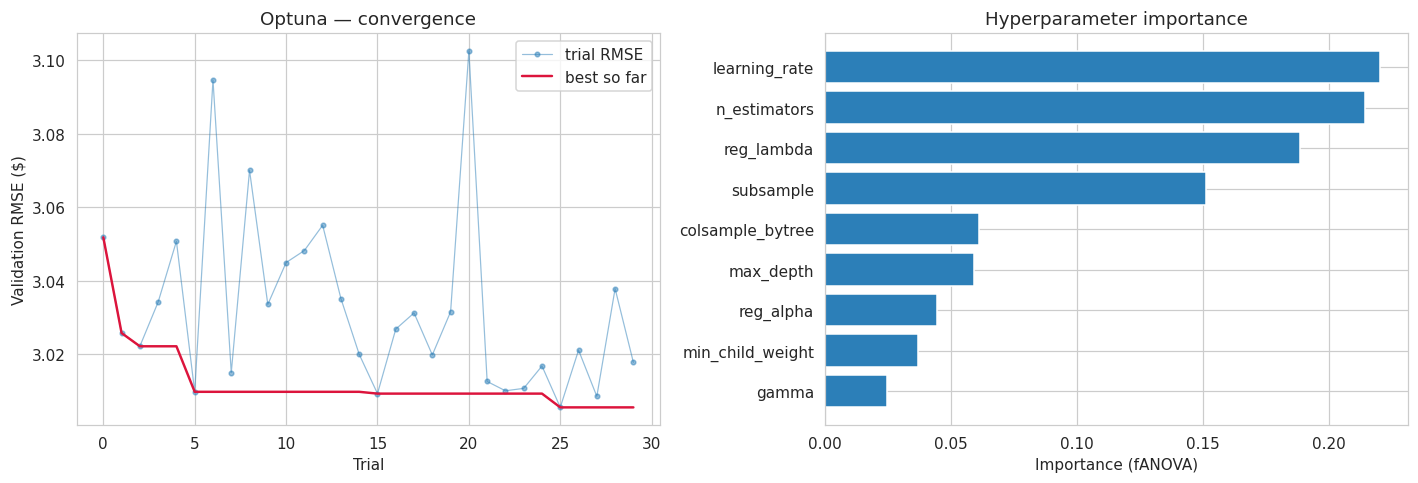

In [ ]:
# optimization history + param importance

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

trials_df = study.trials_dataframe()

axes[0].plot(trials_df["number"], trials_df["value"], marker="o", markersize=3,
             linewidth=0.8, color="#2c7fb8", alpha=0.5, label="trial RMSE")
axes[0].plot(trials_df["number"], trials_df["value"].cummin(),
             color="crimson", linewidth=1.6, label="best so far")

axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation RMSE ($)")
axes[0].set_title("Optuna — convergence")
axes[0].legend(loc="upper right")


try:

    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.Series(importances).sort_values()
    
    axes[1].barh(imp_df.index, imp_df.values, color="#2c7fb8")
    axes[1].set_xlabel("Importance (fANOVA)")
    axes[1].set_title("Hyperparameter importance")

except Exception as e:
    axes[1].text(0.5, 0.5, f"importance unavailable\n({type(e).__name__})",
                 ha="center", va="center", transform=axes[1].transAxes)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "optuna_search.png")
plt.show()

## 13. K-Fold Cross-Validation with Best Params

Evaluate the winning config honestly on the **full 1.5M `eval_sample`** using `CV_FOLDS`-fold CV. This replaces the baseline's single 80/20 split. The reported metric becomes mean ± std across folds.

**Why K-fold matters.** A single 80/20 split gives a point estimate $\hat{R}$ whose variance scales as $\sigma^2 / n_{test}$. K-fold averages K such estimates, each on a different held-out fold, then reports the mean and the *empirical* standard deviation across folds.

In [ ]:
# best Optuna params + fixed compute params

final_params = {
    **study.best_params,
    "objective":          "reg:squarederror",
    "eval_metric":        "rmse",
    "tree_method":        "hist",
    "device":             XGB_DEVICE,
    "enable_categorical": True,
    "random_state":       SEED,
    "verbosity":          0,
}

X_all = eval_sample[ALL_FEATURES]
y_all = eval_sample[TARGET]

kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold_i, (tr_idx, va_idx) in enumerate(kfold.split(X_all), start=1):

    X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
    y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]

    model = xgb.XGBRegressor(**final_params, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    preds = model.predict(X_va)

    rmse = float(np.sqrt(mean_squared_error(y_va, preds)))
    mae = float(mean_absolute_error(y_va, preds))
    r2 = float(r2_score(y_va, preds))
    
    fold_metrics.append({"fold": fold_i, "rmse": rmse, "mae": mae, "r2": r2})

    print(f"  Fold {fold_i}/{CV_FOLDS} — RMSE ${rmse:.3f} | MAE ${mae:.3f} | R² {r2:.4f}")

cv_df = pd.DataFrame(fold_metrics)
cv_summary = cv_df.agg(["mean", "std"]).round(4)

print("\n" + "=" * 60)
print(f" {CV_FOLDS}-FOLD CV SUMMARY")
print("=" * 60)
print(f"  RMSE : ${cv_summary.loc['mean', 'rmse']:.3f} ± ${cv_summary.loc['std', 'rmse']:.3f}")
print(f"  MAE  : ${cv_summary.loc['mean', 'mae']:.3f} ± ${cv_summary.loc['std', 'mae']:.3f}")
print(f"  R²   : {cv_summary.loc['mean', 'r2']:.4f} ± {cv_summary.loc['std', 'r2']:.4f}")

cv_df.to_csv(METRICS_DIR / "kfold_cv_metrics.csv", index=False)

  Fold 1/5 — RMSE $2.980 | MAE $1.913 | R² 0.9672
  Fold 2/5 — RMSE $2.984 | MAE $1.916 | R² 0.9672
  Fold 3/5 — RMSE $3.000 | MAE $1.912 | R² 0.9669
  Fold 4/5 — RMSE $2.988 | MAE $1.912 | R² 0.9673
  Fold 5/5 — RMSE $2.970 | MAE $1.913 | R² 0.9675

 5-FOLD CV SUMMARY
  RMSE : $2.985 ± $0.011
  MAE  : $1.913 ± $0.002
  R²   : 0.9672 ± 0.0002


## 14. Final Model — Refit on All `eval_sample`, Evaluate on Held-Out 20%

Held-out test set with the tuned params.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED)

model_final = xgb.XGBRegressor(**final_params, n_jobs=-1)
model_final.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = model_final.predict(X_test)

rmse_v2 = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae_v2 = float(mean_absolute_error(y_test, y_pred))
r2_v2 = float(r2_score(y_test, y_pred))

print(f"v2 tuned (held-out 20%) — RMSE: ${rmse_v2:.3f} | MAE: ${mae_v2:.3f} | R²: {r2_v2:.4f}")

v2 tuned (held-out 20%) — RMSE: $2.979 | MAE: $1.913 | R²: 0.9672


## 15. Comparison vs Baseline

Baseline figures are pulled from the v1 notebook's saved metrics JSON if it exists; otherwise fall back to the published baseline (RMSE $3.82, R² 0.947).

In [ ]:
# load the real baseline metrics; fall back to the known values from the v1

baseline_json = DRIVE_BASE / "baseline_fare" / "metrics" / "fare_baseline_metrics.json"

if baseline_json.exists():

    with open(baseline_json) as f:
        bl = json.load(f)["xgboost"]
        
    rmse_v1, mae_v1, r2_v1 = bl["rmse"], bl["mae"], bl["r2"]
    src = "loaded from baseline JSON"

else:
    rmse_v1, mae_v1, r2_v1 = 3.82, 1.85, 0.947
    src = "fallback (baseline JSON not found)"

cmp_df = pd.DataFrame({
    "Model":   ["XGBoost (baseline)", "XGBoost (v2 tuned)"],
    "RMSE ($)": [rmse_v1, rmse_v2],
    "MAE ($)":  [mae_v1,  mae_v2],
    "R²":       [r2_v1,   r2_v2],
}).round({"RMSE ($)": 3, "MAE ($)": 3, "R²": 4})

rmse_lift = (rmse_v1 - rmse_v2) / rmse_v1 * 100
r2_lift   = (r2_v2 - r2_v1) * 100

cmp_df.to_csv(METRICS_DIR / "v2_vs_baseline.csv", index=False)

print(f"Baseline source: {src}\n")
print(cmp_df.to_string(index=False))
print()
print(f"  RMSE  : {rmse_lift:+.1f}% vs baseline")
print(f"  R²    : {r2_lift:+.2f} pp vs baseline")

Baseline source: loaded from baseline JSON

             Model  RMSE ($)  MAE ($)     R²
XGBoost (baseline)     3.816    2.119 0.9474
XGBoost (v2 tuned)     2.979    1.913 0.9672

  RMSE  : +21.9% vs baseline
  R²    : +1.98 pp vs baseline


## 16. Deck Artifact — Predicted vs Actual

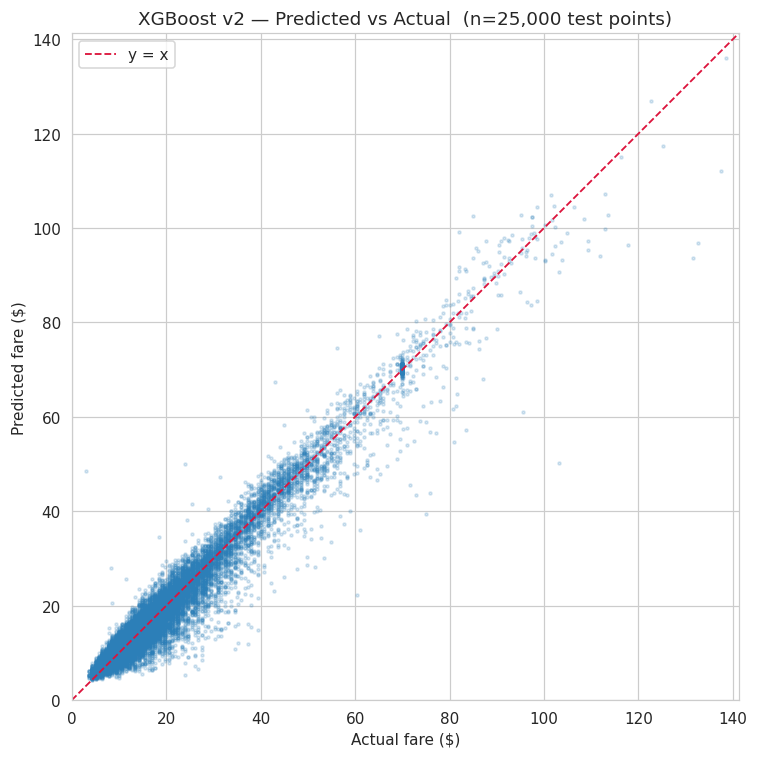

In [ ]:
plot_n = 25_000

idx = np.random.RandomState(SEED).choice(len(y_test), size=min(plot_n, len(y_test)), replace=False)

y_t = np.asarray(y_test)[idx]
y_p = y_pred[idx]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_t, y_p, s=4, alpha=0.18, color="#2c7fb8")

lim_max = max(y_t.max(), y_p.max()) * 1.02

ax.plot([0, lim_max], [0, lim_max], color="crimson", linestyle="--", linewidth=1.2, label="y = x")
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_xlabel("Actual fare ($)")
ax.set_ylabel("Predicted fare ($)")
ax.set_title(f"XGBoost v2 — Predicted vs Actual  (n={len(idx):,} test points)")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_pred_vs_actual.png")

plt.show()

## 17. Deck Artifact — Residuals

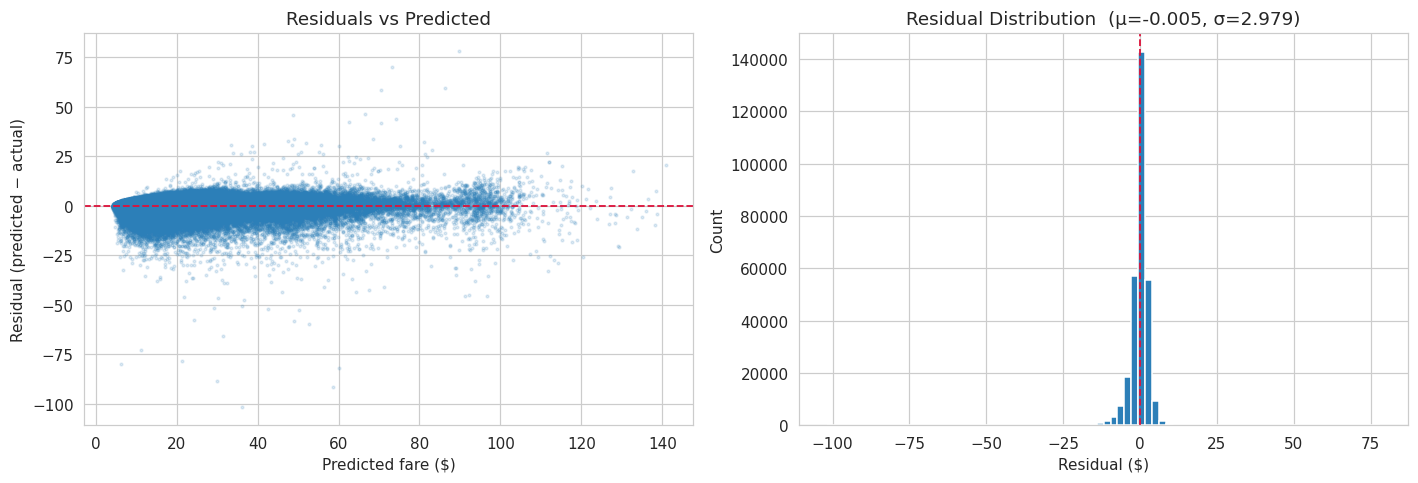

In [ ]:
resid = y_pred - np.asarray(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred, resid, s=3, alpha=0.15, color="#2c7fb8")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted fare ($)")
axes[0].set_ylabel("Residual (predicted − actual)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(resid, bins=80, color="#2c7fb8", edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution  (μ={resid.mean():.3f}, σ={resid.std():.3f})")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_residuals.png")

plt.show()

## 18. Deck Artifact — Feature Importance

Because we're on native categorical, importance comes back at the source-feature level directly. No OHE-aggregation cell needed.

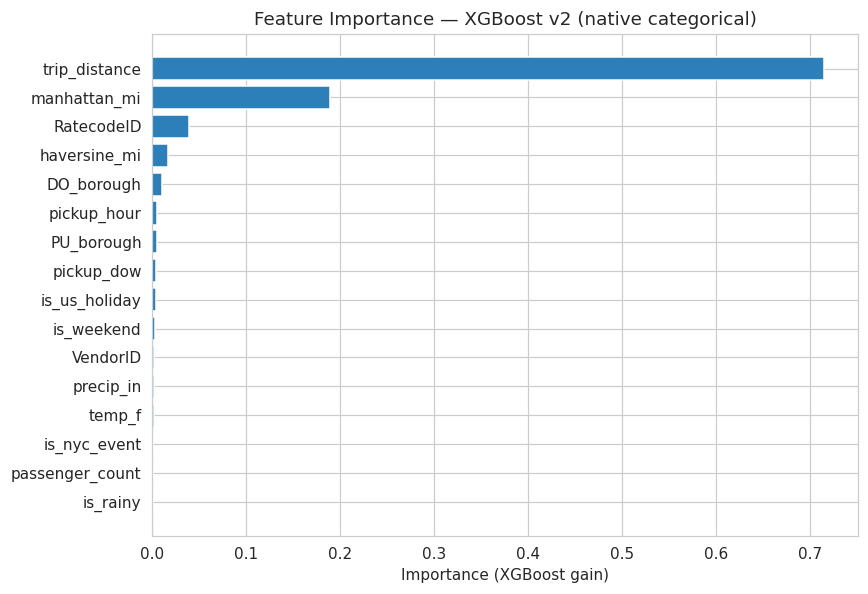

,feature,importance
15,trip_distance,0.7156
14,manhattan_mi,0.1889
13,RatecodeID,0.0390
12,haversine_mi,0.0164
11,DO_borough,0.0104
10,pickup_hour,0.0053
9,PU_borough,0.0051
8,pickup_dow,0.0041
7,is_us_holiday,0.0037
6,is_weekend,0.0028


In [ ]:
imp_df = (pd.DataFrame({
    "feature":    model_final.feature_names_in_,
    "importance": model_final.feature_importances_,
}).sort_values("importance", ascending=True).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(imp_df["feature"], imp_df["importance"], color="#2c7fb8")
ax.set_xlabel("Importance (XGBoost gain)")
ax.set_title("Feature Importance — XGBoost v2 (native categorical)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_feature_importance.png")

plt.show()

imp_df.sort_values("importance", ascending=False).round(4)

## 19. Residual Investigation

1. **Worst-50 by |residual|.** A table can be scanned for patterns.
2. **Residual slices.** Mean and 95th-percentile absolute residual binned by fare, distance, hour, and borough pair. If any one bin's |residual| dwarfs the others, that's a tighter-bound candidate.

In [ ]:
abs_resid = np.abs(resid)
worst_idx = np.argsort(abs_resid)[-50:][::-1]

worst = X_test.iloc[worst_idx].copy()
worst.insert(0, "predicted_fare", np.round(y_pred[worst_idx], 2))
worst.insert(0, "actual_fare", np.round(np.asarray(y_test)[worst_idx], 2))
worst.insert(0, "residual", np.round(resid[worst_idx], 2))
worst = worst.reset_index(drop=True)
worst.to_csv(METRICS_DIR / "v2_worst_residuals.csv", index=False)

print("Top 50 worst misses — saved to v2_worst_residuals.csv")
print(f"Range of |residual| in worst-50 : ${abs_resid[worst_idx].min():.2f} – ${abs_resid[worst_idx].max():.2f}")

worst.head(15)

Top 50 worst misses — saved to v2_worst_residuals.csv
Range of |residual| in worst-50 : $36.12 – $101.85


,residual,actual_fare,predicted_fare,trip_distance,passenger_count,haversine_mi,manhattan_mi,temp_f,precip_in,pickup_hour,pickup_dow,is_weekend,PU_borough,DO_borough,VendorID,RatecodeID,is_us_holiday,is_nyc_event,is_rainy
0,-101.85,138.00,36.150002,0.60,1.0,0.000000,0.00000,46.6,0.000,0,0,0,Manhattan,Manhattan,1,5,0,0,0
1,-91.44,150.00,58.560001,11.78,1.0,0.000000,0.00000,71.2,0.000,9,1,0,Queens,Queens,2,5,0,0,0
2,-88.53,118.50,29.969999,4.86,1.0,0.000000,0.00000,58.6,0.000,15,4,0,Manhattan,Manhattan,2,1,0,0,0
3,-82.18,142.30,60.119999,13.33,1.0,0.000000,0.00000,73.3,0.035,19,4,0,Manhattan,Manhattan,2,1,0,0,0
4,-79.74,86.00,6.260000,0.50,1.0,0.000000,0.00000,43.2,0.000,17,1,0,Manhattan,Manhattan,1,5,0,0,0
5,-78.59,100.00,21.410000,0.41,1.0,0.000000,0.00000,67.5,0.000,3,5,1,Manhattan,Manhattan,2,5,0,0,0
6,78.19,11.51,89.699997,19.40,1.0,9.976598,13.04385,60.7,0.646,17,0,0,Manhattan,Queens,2,5,0,0,1
7,-72.74,84.00,11.260000,0.80,2.0,0.000000,0.00000,38.2,0.000,17,5,1,Manhattan,Manhattan,2,5,0,0,0
8,70.12,3.00,73.120003,17.50,1.0,9.976598,13.04385,53.2,0.000,18,4,0,Manhattan,Queens,1,1,0,0,0
9,-65.95,97.50,31.549999,1.46,1.0,0.000000,0.00000,67.7,0.000,20,1,0,Manhattan,Manhattan,2,5,0,0,0


In [ ]:
diag = pd.DataFrame({
    "actual":        np.asarray(y_test),
    "pred":          y_pred,
    "abs_res":       abs_resid,
    "trip_distance": X_test[COL["trip_distance"]].to_numpy(),
    "hour":          X_test[COL["hour"]].astype(int).to_numpy(),
    "pu":            X_test[COL["pu_borough"]].astype(str).to_numpy(),
    "do":            X_test[COL["do_borough"]].astype(str).to_numpy(),
})

# fare (dollars)

diag["fare_bin"] = pd.cut(diag["actual"],
                          bins=[0, 5, 10, 20, 40, 80, FARE_MAX + 1],
                          labels=["≤5", "5–10", "10–20", "20–40", "40–80", ">80"])

#distance (miles)

diag["dist_bin"] = pd.cut(diag["trip_distance"],
                          bins=[0, 1, 3, 7, 15, DIST_MAX + 1],
                          labels=["≤1", "1–3", "3–7", "7–15", ">15"])

def _slice_table(group_col: str) -> pd.DataFrame:

    g = diag.groupby(group_col, observed=True)["abs_res"]

    return pd.DataFrame({
        "n":        g.size(),
        "mean_|r|": g.mean().round(3),
        "p95_|r|":  g.quantile(0.95).round(3),
        "max_|r|":  g.max().round(3),
    }).sort_values("mean_|r|", ascending=False)

print("── By fare bin ──"); print(_slice_table("fare_bin")); print()
print("── By distance bin ──"); print(_slice_table("dist_bin")); print()
print("── By pickup borough ──");print(_slice_table("pu")); print()

── By fare bin ──
               n  mean_|r|  p95_|r|  max_|r|
fare_bin                                    
>80         1677     6.842   21.341  101.853
20–40      52408     3.036    8.834   59.295
40–80      29991     2.367    9.010   46.754
10–20     120640     1.813    4.866   78.186
≤5          2425     1.342    2.459   70.122
5–10       92858     1.189    2.978   30.078

── By distance bin ──
               n  mean_|r|  p95_|r|  max_|r|
dist_bin                                    
7–15       23826     2.978    8.287   91.443
3–7        46649     2.509    6.881   88.529
1–3       148509     1.874    5.144   65.950
≤1         65845     1.343    3.699  101.853
>15        15170     1.263    6.085   78.186

── By pickup borough ──
                    n  mean_|r|  p95_|r|  max_|r|
pu                                               
EWR                 2    15.235   18.294   18.634
Staten Island      12     6.697   17.174   17.258
Bronx             369     3.179    9.893   30.524
Brooklyn 

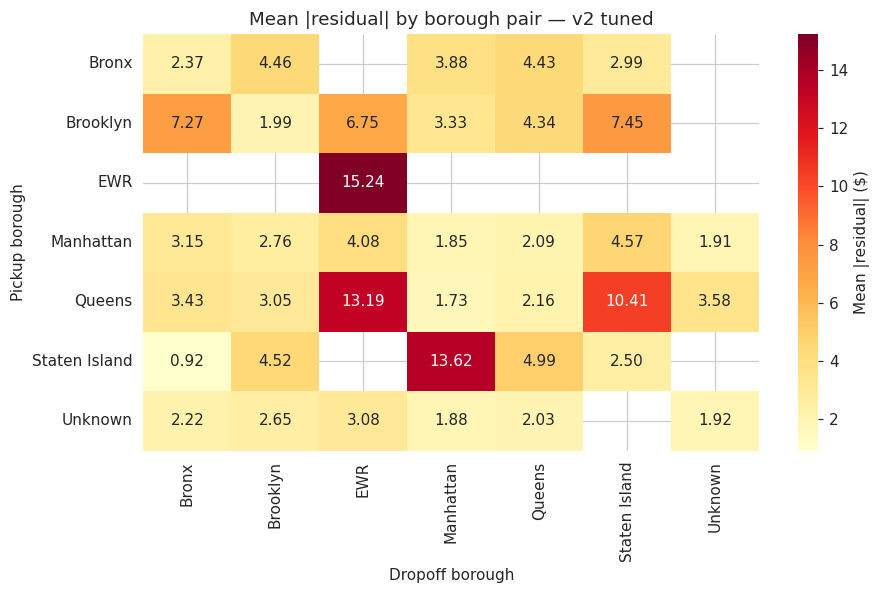

In [ ]:
# residual heatmap (PU, DO) borough 

heat = diag.pivot_table(index="pu", columns="do", values="abs_res", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "Mean |residual| ($)"}, ax=ax)

ax.set_xlabel("Dropoff borough")
ax.set_ylabel("Pickup borough")
ax.set_title("Mean |residual| by borough pair — v2 tuned")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_residual_borough_heatmap.png")

plt.show()

Any fare or distance bin whose `mean_|r|` is ≥ 2× the overall mean is a candidate for either:

- **Tighter sanity bounds** (drop rows in that bin from training), or
- **A specific feature** (e.g., explicit `is_airport_trip` flag if airport pickups dominate the fare-bin).

Cross-reference the worst-50 CSV with the slice tables..

## 20. Full-Dataset Run *(gated — set `USE_FULL_DATASET = True` to enable)*

Retrain on the entire cleaned parquet (~30M rows), use `xgb.QuantileDMatrix` for the data path because it builds the histogram bins from a quantile sketch instead of holding the full dense matrix in memory.

In [ ]:
if USE_FULL_DATASET:

    print(f"Training on full cleaned parquet: {len(df_clean):,} rows")

    X_full = df_clean[ALL_FEATURES]
    y_full = df_clean[TARGET]

    X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.1, random_state=SEED)

    # QuantileDMatrix

    dtrain = xgb.QuantileDMatrix(X_tr, label=y_tr, enable_categorical=True)
    dtest = xgb.QuantileDMatrix(X_te, label=y_te, enable_categorical=True, ref=dtrain)

    booster = xgb.train(
        params={**{k: v for k, v in final_params.items() if k != "n_estimators"}},
        dtrain=dtrain,
        num_boost_round=final_params["n_estimators"],
        evals=[(dtest, "test")],
        early_stopping_rounds=50,
        verbose_eval=100,
    )

    pred_full = booster.predict(dtest)
    rmse_full = float(np.sqrt(mean_squared_error(y_te, pred_full)))
    mae_full = float(mean_absolute_error(y_te, pred_full))
    r2_full = float(r2_score(y_te, pred_full))

    print(f"\nFull-dataset — RMSE: ${rmse_full:.3f} | MAE: ${mae_full:.3f} | R²: {r2_full:.4f}")

    booster.save_model(str(OUTPUT_DIR / "xgb_v2_full.json"))

else:
    print("Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.")
    
    rmse_full = mae_full = r2_full = None

Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.


## 21. Summary

In [ ]:
summary = {
    "baseline": {"rmse": rmse_v1, "mae": mae_v1, "r2": r2_v1},
    "v2_tuned_holdout":  {"rmse": rmse_v2, "mae": mae_v2, "r2": r2_v2},
    "v2_tuned_kfold": {
        "k": CV_FOLDS,
        "rmse_mean": float(cv_summary.loc["mean", "rmse"]),
        "rmse_std":  float(cv_summary.loc["std",  "rmse"]),
        "mae_mean":  float(cv_summary.loc["mean", "mae"]),
        "mae_std":   float(cv_summary.loc["std",  "mae"]),
        "r2_mean":   float(cv_summary.loc["mean", "r2"]),
        "r2_std":    float(cv_summary.loc["std",  "r2"]),
    },
    "v2_tuned_full":  ({"rmse": rmse_full, "mae": mae_full, "r2": r2_full}
                       if USE_FULL_DATASET else None),
    "best_params":    study.best_params,
    "n_trials":       N_TRIALS,
    "sample_size":    SAMPLE_SIZE,
    "tuning_sample":  TUNING_SAMPLE,
    "features":       ALL_FEATURES,
    "fare_bounds":    [FARE_MIN, FARE_MAX],
    "dist_bounds":    [DIST_MIN, DIST_MAX],
    "seed":           SEED,
}

with open(METRICS_DIR / "v2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 64)
print(" v2 TUNED FARE MODEL — DECK SUMMARY")
print("=" * 64)
print(f"  Baseline XGBoost      : RMSE ${rmse_v1:.2f}  | MAE ${mae_v1:.2f}  | R² {r2_v1:.3f}")
print(f"  v2 tuned (held-out)   : RMSE ${rmse_v2:.2f}  | MAE ${mae_v2:.2f}  | R² {r2_v2:.3f}")
print(f"  v2 tuned ({CV_FOLDS}-fold CV)  : RMSE ${cv_summary.loc['mean','rmse']:.2f} "
      f"± ${cv_summary.loc['std','rmse']:.2f}  |  R² {cv_summary.loc['mean','r2']:.3f} "
      f"± {cv_summary.loc['std','r2']:.3f}")

if USE_FULL_DATASET:
    print(f"  v2 tuned (full data)  : RMSE ${rmse_full:.2f}  | MAE ${mae_full:.2f}  | R² {r2_full:.3f}")
    
print()
print(f"  Improvements vs baseline : RMSE {rmse_lift:+.1f}%   R² {r2_lift:+.2f} pp")
print()
print(f"  Figures saved to : {FIGURE_DIR}")
print(f"  Metrics saved to : {METRICS_DIR}")

 v2 TUNED FARE MODEL — DECK SUMMARY
  Baseline XGBoost      : RMSE $3.82  | MAE $2.12  | R² 0.947
  v2 tuned (held-out)   : RMSE $2.98  | MAE $1.91  | R² 0.967
  v2 tuned (5-fold CV)  : RMSE $2.98 ± $0.01  |  R² 0.967 ± 0.000

  Improvements vs baseline : RMSE +21.9%   R² +1.98 pp

  Figures saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_fare/figures
  Metrics saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_fare/metrics


## 22. Next Steps

**Modeling:**
- Run Optuna with `N_TRIALS=100+` overnight; current 30-trial run as starting point.
- Add a stacked ensemble (XGBoost + LightGBM + CatBoost) with a Ridge meta-learner.
- Promote `PU_borough`/`DO_borough` to full `PULocationID`/`DOLocationID` (263 zones) once a zone-centroid lookup is bundled. Native categorical handles the cardinality without OHE blowup.

**Pipeline / repo:**
- Lift `objective()`, the K-fold loop, and the feature-engineering blocks into `src/fare_v2.py` for the OOP refactor.
- Persist `optuna_best_params.json` to `models/fare_v2/` and version it.

**For the deck:**
- `v2_vs_baseline.csv` -> metrics-comparison table.
- `v2_pred_vs_actual.png` -> main visual.
- `optuna_search.png` -> convergence + hyperparam importance.
- `v2_feature_importance.png` -> talking-point anchor.
- `v2_residual_borough_heatmap.png` -> diagnostic.